# Appointment No Show Analysis

In [1]:
import pandas as pd
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data/healthcare_noshows_appt.csv')

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [4]:
df.dtypes

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship          bool
Hipertension         bool
Diabetes             bool
Alcoholism           bool
Handcap              bool
SMS_received         bool
Showed_up            bool
Date.diff           int64
dtype: object

In [5]:
diabetes_phrases = [
    "diabetes follow-up",
    "blood glucose monitoring",
    'insulin adherence discussed'
]

htn_phrases = [
    'hypertension follow-up',
    'blood pressure check',
    'reviewing BP medications'
]

alcohol_phrases = [
    'alcohol use discussed',
    'counseled on alcohol intake',
    'history of alcohol use noted'
]

barrier_phrases = [
    'transportation issues reported',
    'difficulty attending appointment',
    'schedule conflict noted'
]

stable_phrases = [
    'symptoms improving',
    'adherent to treatment',
    'no acute complaints'
]

In [6]:
import random

def generate_note(row):
    note_parts = []

    #Base statement
    note_parts.append(random.choice([
                      "Patient presents for visit",
                      'Routine follow-up',
                      'Scheduled appointment'
    ]))

    #Condition-driven mentions (probabilistic, not guaranteed)
    if row['Diabetes'] and random.random() <0.7:
        note_parts.append(random.choice(diabetes_phrases))

    if row['Hipertension'] and random.random() <0.7:
        note_parts.append(random.choice(htn_phrases))

    if row['Alcoholism'] and random.random() <0.6:
        note_parts.append(random.choice(alcohol_phrases))

    #Behavioral signfal tied to outcome
    if row['Showed_up'] == False:
        if random.random() <0.7:
            note_parts.append(random.choice(barrier_phrases))
        else: 
            if random.random() <0.6:
                note_parts.append(random.choice(stable_phrases))

    return ". ".join(note_parts)


In [7]:
df['Visit_Notes'] = df.apply(generate_note, axis=1)

In [8]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff,Visit_Notes
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0,Routine follow-up
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0,Routine follow-up
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0,Scheduled appointment
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0,Patient presents for visit
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0,Patient presents for visit. blood glucose moni...


In [9]:
duckdb.query("""
CREATE TABLE appointments AS
SELECT * FROM read_csv_auto('./data/healthcare_noshows_appt.csv')
""")

## Which patient demographic groups have the highest no-show rates?

In [10]:
duckdb.query("""
SELECT DISTINCT Showed_up
FROM appointments""")

┌───────────┐
│ Showed_up │
│  boolean  │
├───────────┤
│ false     │
│ true      │
└───────────┘

In [11]:
duckdb.query("""
SELECT COUNT(*) FROM appointments""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       106987 │
└──────────────┘

### Gender and Age

In [12]:
duckdb.query("""

WITH base AS (
  SELECT gender,
         CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END AS no_show_flag
  FROM appointments
)

SELECT gender,
       SUM(no_show_flag) AS no_show_count,
       AVG(no_show_flag) AS no_show_rate
FROM base
GROUP BY gender

""")

┌─────────┬───────────────┬─────────────────────┐
│ Gender  │ no_show_count │    no_show_rate     │
│ varchar │    int128     │       double        │
├─────────┼───────────────┼─────────────────────┤
│ F       │         14275 │ 0.20358538463732564 │
│ M       │          7405 │ 0.20084623938810384 │
└─────────┴───────────────┴─────────────────────┘

In [13]:
duckdb.query("""
WITH base AS(
SELECT *,
    CASE 
        WHEN age < 18 THEN 'pediatric'
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
    END AS age_groups,

    CASE WHEN Showed_up = False THEN 1 
        ELSE 0 
    END AS no_show_flag
    
FROM appointments)

SELECT age_groups,
SUM(no_show_flag) AS no_show_count,
AVG(no_show_flag) AS no_show_rate,
COUNT(*) AS total_count

FROM base
GROUP BY age_groups
ORDER BY no_show_rate DESC;

""")

┌────────────┬───────────────┬─────────────────────┬─────────────┐
│ age_groups │ no_show_count │    no_show_rate     │ total_count │
│  varchar   │    int128     │       double        │    int64    │
├────────────┼───────────────┼─────────────────────┼─────────────┤
│ 18-25      │          2821 │  0.2514260249554367 │       11220 │
│ 26-35      │          3282 │ 0.22785337406276035 │       14404 │
│ pediatric  │          5358 │   0.224748322147651 │       23840 │
│ 36-45      │          3082 │  0.2113564668769716 │       14582 │
│ 46-55      │          2834 │ 0.18358489343784415 │       15437 │
│ senior     │           870 │ 0.16135014836795253 │        5392 │
│ 56-65      │          2237 │ 0.15750193621065972 │       14203 │
│ 66-75      │          1196 │ 0.15122012896699963 │        7909 │
└────────────┴───────────────┴─────────────────────┴─────────────┘

In [14]:
duckdb.query("""

CREATE VIEW appointments_vw AS

SELECT *,
    CASE 
        WHEN age < 18 THEN 'pediatric'
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
    END AS age_groups,

    CASE WHEN Showed_up = False THEN 1 
        ELSE 0 
    END AS no_show_flag
    
FROM appointments;

""")

### Medical Diagnosis

In [15]:
duckdb.query("""

SELECT diabetes, gender,
SUM(no_show_flag) as no_show_count,
COUNT(*) AS total_count,
AVG(no_show_flag) as no_show_rate,


FROM appointments_vw
GROUP BY diabetes, gender
ORDER BY no_show_rate DESC;

""")

┌──────────┬─────────┬───────────────┬─────────────┬─────────────────────┐
│ Diabetes │ Gender  │ no_show_count │ total_count │    no_show_rate     │
│ boolean  │ varchar │    int128     │    int64    │       double        │
├──────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ false    │ F       │         13258 │       64512 │  0.2055121527777778 │
│ false    │ M       │          6992 │       34532 │ 0.20247886018765204 │
│ true     │ F       │          1017 │        5606 │  0.1814127720299679 │
│ true     │ M       │           413 │        2337 │ 0.17672229353872487 │
└──────────┴─────────┴───────────────┴─────────────┴─────────────────────┘

In [16]:
duckdb.query("""

SELECT hipertension, gender,
SUM(no_show_flag) AS no_show_count,
COUNT(*) AS total_count,
AVG(no_show_flag) AS no_show_rate,
FROM appointments_vw
GROUP BY hipertension, gender
ORDER BY no_show_rate DESC;

""")

┌──────────────┬─────────┬───────────────┬─────────────┬─────────────────────┐
│ Hipertension │ Gender  │ no_show_count │ total_count │    no_show_rate     │
│   boolean    │ varchar │    int128     │    int64    │       double        │
├──────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ false        │ F       │         11618 │       54779 │  0.2120885740886106 │
│ false        │ M       │          6290 │       30407 │ 0.20686026243956984 │
│ true         │ F       │          2657 │       15339 │ 0.17321859312862636 │
│ true         │ M       │          1115 │        6462 │ 0.17254719900959456 │
└──────────────┴─────────┴───────────────┴─────────────┴─────────────────────┘

In [17]:
duckdb.query("""

SELECT alcoholism, gender,
SUM(no_show_flag) AS no_show_count,
COUNT(*) AS total_count,
AVG(no_show_flag) AS no_show_rate

FROM appointments_vw
GROUP BY alcoholism, gender
ORDER BY no_show_rate DESC;

""")

┌────────────┬─────────┬───────────────┬─────────────┬─────────────────────┐
│ Alcoholism │ Gender  │ no_show_count │ total_count │    no_show_rate     │
│  boolean   │ varchar │    int128     │    int64    │       double        │
├────────────┼─────────┼───────────────┼─────────────┼─────────────────────┤
│ true       │ F       │           308 │        1223 │  0.2518397383483238 │
│ false      │ F       │         13967 │       68895 │  0.2027287901879672 │
│ false      │ M       │          7036 │       34732 │ 0.20257975354140273 │
│ true       │ M       │           369 │        2137 │ 0.17267197005147403 │
└────────────┴─────────┴───────────────┴─────────────┴─────────────────────┘

In [18]:
duckdb.query("""

SELECT age_groups, diabetes,
SUM(no_show_flag) AS no_show_count,
COUNT(*) AS total_count,
AVG(no_show_flag) AS no_show_rate

FROM appointments_vw
GROUP BY age_groups, diabetes
ORDER BY age_groups, diabetes DESC;

""")

┌────────────┬──────────┬───────────────┬─────────────┬─────────────────────┐
│ age_groups │ Diabetes │ no_show_count │ total_count │    no_show_rate     │
│  varchar   │ boolean  │    int128     │    int64    │       double        │
├────────────┼──────────┼───────────────┼─────────────┼─────────────────────┤
│ 18-25      │ true     │            13 │          50 │                0.26 │
│ 18-25      │ false    │          2808 │       11170 │ 0.25138764547896153 │
│ 26-35      │ true     │            49 │         176 │  0.2784090909090909 │
│ 26-35      │ false    │          3233 │       14228 │ 0.22722800112454317 │
│ 36-45      │ true     │           133 │         675 │ 0.19703703703703704 │
│ 36-45      │ false    │          2949 │       13907 │ 0.21205148486373768 │
│ 46-55      │ true     │           280 │        1448 │ 0.19337016574585636 │
│ 46-55      │ false    │          2554 │       13989 │  0.1825720208735435 │
│ 56-65      │ true     │           406 │        2436 │ 0.166666

## Key Findings
1. Age is the strongest driver of no-show behavior
Patients aged 18–25 consistently show the highest no-show rates (around 25%)
Older patients (66–75) show lower no-show rates (around 15%)
This pattern is consistent across most subgroups
2. Gender has minimal independent effect
No-show rates are similar between males and females overall
Differences within age groups are small and inconsistent
3. Diabetes is largely confounded by age
Initial differences by diabetes status are explained by age distribution
No consistent independent effect observed after stratification
4. Alcoholism shows weak interaction effects
Some variation observed by gender and age
However, patterns are not consistent enough to suggest a strong independent effect

## Conclusion
No-show behavior is primarily structured by age, with younger patients showing consistently higher rates of missed appointments. Clinical variables such as diabetes and alcoholism do not independently explain no-show behavior once age is accounted for. Gender shows minimal influence overall.
The results suggest that demographic factors, particularly age, are more predictive of appointment adherence than individual clinical conditions in this dataset.

## How does wait time between scheduling and appointment date affect no-show probability?

In [19]:
duckdb.query("""
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'appointments'
AND column_name IN ('scheduledday', 'appointmentday')
""")

┌─────────────┬───────────┐
│ column_name │ data_type │
│   varchar   │  varchar  │
└─────────────┴───────────┘
          0 rows         

In [20]:
duckdb.query("""

SELECT PatientId,
    ScheduledDay,
    AppointmentDay,
    CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days
FROM appointments
LIMIT 10;

""")

┌───────────────────┬──────────────┬────────────────┬───────────┐
│     PatientId     │ ScheduledDay │ AppointmentDay │ wait_days │
│      double       │     date     │      date      │   int64   │
├───────────────────┼──────────────┼────────────────┼───────────┤
│  29872499824296.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│ 558997776694438.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│   4262962299951.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│    867951213174.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│   8841186448183.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│  95985133231274.0 │ 2016-04-27   │ 2016-04-29     │         2 │
│ 733688164476661.0 │ 2016-04-27   │ 2016-04-29     │         2 │
│   3449833394123.0 │ 2016-04-27   │ 2016-04-29     │         2 │
│  56394729949972.0 │ 2016-04-29   │ 2016-04-29     │         0 │
│  78124564369297.0 │ 2016-04-27   │ 2016-04-29     │         2 │
└───────────────────┴──────────────┴────────────────┴───────────┘
  10 rows 

In [21]:
duckdb.query("""

SELECT
    AppointmentId,
    CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days,
    CASE
        WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) = 0 THEN 'Same Day'
        WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 1 AND 7 THEN '1-7 Days'
        WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 8 AND 14 THEN '8-14 Days'
        WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 15 AND 30 THEN '15-30 Days'
        WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) > 30 THEN '30+ Days'
    END AS wait_bucket
FROM appointments;
""")

┌───────────────┬───────────┬─────────────┐
│ AppointmentID │ wait_days │ wait_bucket │
│     int64     │   int64   │   varchar   │
├───────────────┼───────────┼─────────────┤
│       5642903 │         0 │ Same Day    │
│       5642503 │         0 │ Same Day    │
│       5642549 │         0 │ Same Day    │
│       5642828 │         0 │ Same Day    │
│       5642494 │         0 │ Same Day    │
│       5626772 │         2 │ 1-7 Days    │
│       5630279 │         2 │ 1-7 Days    │
│       5630575 │         2 │ 1-7 Days    │
│       5638447 │         0 │ Same Day    │
│       5629123 │         2 │ 1-7 Days    │
│          ·    │         · │    ·        │
│          ·    │         · │    ·        │
│          ·    │         · │    ·        │
│       5722103 │         0 │ Same Day    │
│       5541843 │        31 │ 30+ Days    │
│       5567542 │        32 │ 30+ Days    │
│       5585395 │        36 │ 30+ Days    │
│       5544511 │        31 │ 30+ Days    │
│       5559744 │        35 │ 30

In [22]:
result = duckdb.query("""

WITH wait_calc AS (
    SELECT
        CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days,
        CASE
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) = 0 THEN 'Same Day'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 1 AND 7 THEN '1-7 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 8 AND 14 THEN '8-14 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 15 AND 30 THEN '15-30 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) > 30 THEN '30+ Days'
        END AS wait_bucket,
         
         CASE 
            WHEN age < 18 THEN 'pediatric'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
        END AS age_group,
        Showed_up,
        AppointmentDay,
        ScheduledDay
    FROM appointments
    )

SELECT
    wait_bucket,
    age_group,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) AS no_shows,
    ROUND(
        AVG(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) * 100,
        2
    ) AS no_show_rate
FROM wait_calc
WHERE (CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE)) >= 0
GROUP BY wait_bucket, age_group
ORDER BY wait_bucket, age_group;

""").to_df()

result.sort_values('no_show_rate', ascending=False)

,wait_bucket,age_group,total_appointments,no_shows,no_show_rate
16,30+ Days,18-25,892,370.0,41.48
22,30+ Days,pediatric,2168,886.0,40.87
8,15-30 Days,18-25,1949,769.0,39.46
24,8-14 Days,18-25,1347,520.0,38.60
17,30+ Days,26-35,1288,491.0,38.12
9,15-30 Days,26-35,2421,921.0,38.04
14,15-30 Days,pediatric,3708,1346.0,36.30
18,30+ Days,36-45,1298,469.0,36.13
10,15-30 Days,36-45,2375,842.0,35.45
30,8-14 Days,pediatric,2697,919.0,34.07


No-show rates increase substantially with longer scheduling lead times across all age groups. Age further moderates this effect, with younger patients consistently exhibiting higher no-show rates within each wait-time category. However, even among older patients, extended lead times are associated with elevated no-show risk, indicating that scheduling delay is the primary driver of missed appointments.

#### Do patients who receive reminders (SMS or not) show different no-show behavior across age groups?

In [23]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff,Visit_Notes
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0,Routine follow-up
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0,Routine follow-up
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0,Scheduled appointment
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0,Patient presents for visit
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0,Patient presents for visit. blood glucose moni...


In [24]:
sms = duckdb.query("""

WITH base AS (
    SELECT
        SMS_received,
        CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days,
        CASE
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) = 0 THEN 'Same Day'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 1 AND 7 THEN '1-7 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 8 AND 14 THEN '8-14 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 15 AND 30 THEN '15-30 Days'
            ELSE '30+ Days'
        END AS wait_bucket,
        Showed_up
    FROM appointments
    WHERE (CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE)) >= 0
)

SELECT
    SMS_received,
    wait_bucket,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) AS no_shows,
    ROUND(AVG(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) * 100, 2) AS no_show_rate
FROM base
GROUP BY SMS_received, wait_bucket
ORDER BY wait_bucket, SMS_received;

""").to_df()

sms.sort_values('no_show_rate', ascending=False)

,SMS_received,wait_bucket,total_appointments,no_shows,no_show_rate
4,False,30+ Days,3823,1435.0,37.54
2,False,15-30 Days,6536,2420.0,37.03
6,False,8-14 Days,4811,1631.0,33.90
5,True,30+ Days,6173,1880.0,30.46
3,True,15-30 Days,10206,3062.0,30.00
7,True,8-14 Days,6833,1923.0,28.14
0,False,1-7 Days,20073,4880.0,24.31
1,True,1-7 Days,11373,2703.0,23.77
8,False,Same Day,37154,1741.0,4.69


SMS_received is associated with lower no-show rates within longer wait-time categories. However, due to likely non-random assignment of SMS reminders, this relationship may reflect both operational targeting and potential behavioral effects.

In [25]:
sms_age = duckdb.query("""
WITH base AS (
    SELECT
        SMS_received,
        CASE 
            WHEN age < 18 THEN 'pediatric'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
        END AS age_group,
        Showed_up
    FROM appointments
)

SELECT
    SMS_received,
    age_group,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) AS no_shows,
    ROUND(AVG(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) * 100, 2) AS no_show_rate
FROM base
GROUP BY SMS_received, age_group
ORDER BY age_group, SMS_received;

""").to_df()

sms_age.sort_values('no_show_rate', ascending=False)

,SMS_received,age_group,total_appointments,no_shows,no_show_rate
1,True,18-25,3835,1410.0,36.77
3,True,26-35,4894,1570.0,32.08
13,True,pediatric,7124,2209.0,31.01
5,True,36-45,4847,1432.0,29.54
7,True,46-55,5168,1224.0,23.68
15,True,senior,1478,304.0,20.57
9,True,56-65,4719,926.0,19.62
11,True,66-75,2520,493.0,19.56
0,False,18-25,7385,1411.0,19.11
12,False,pediatric,16716,3149.0,18.84


Across all age groups, patients receiving SMS reminders exhibit higher no-show rates compared to those who did not receive SMS. This pattern is consistent across demographics and likely reflects non-random assignment of SMS reminders to higher-risk patients rather than a direct causal effect of SMS increasing no-shows.

In [26]:
sms_all = duckdb.query("""
WITH base AS (
    SELECT
        SMS_received,
        CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days,

        CASE
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) = 0 THEN 'Same Day'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 1 AND 7 THEN '1-7 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 8 AND 14 THEN '8-14 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 15 AND 30 THEN '15-30 Days'
            ELSE '30+ Days'
        END AS wait_bucket,

        CASE 
            WHEN age < 18 THEN 'pediatric'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
        END AS age_group,

        Showed_up
    FROM appointments
    WHERE (CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE)) >= 0
)

SELECT
    wait_bucket,
    age_group,
    SMS_received,
    COUNT(*) AS total_appointments,
    SUM(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) AS no_shows,
    ROUND(AVG(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) * 100, 2) AS no_show_rate
FROM base
GROUP BY wait_bucket, age_group, SMS_received
ORDER BY wait_bucket, age_group, SMS_received;
""").to_df()

sms_all.sort_values('no_show_rate', ascending=False)

,wait_bucket,age_group,SMS_received,total_appointments,no_shows,no_show_rate
44,30+ Days,pediatric,False,827,395.0,47.76
34,30+ Days,26-35,False,493,223.0,45.23
18,15-30 Days,26-35,False,899,392.0,43.60
32,30+ Days,18-25,False,310,135.0,43.55
36,30+ Days,36-45,False,491,210.0,42.77
...,...,...,...,...,...,...
67,Same Day,46-55,False,4963,182.0,3.67
66,Same Day,36-45,False,5058,181.0,3.58
68,Same Day,56-65,False,4361,138.0,3.16
71,Same Day,senior,False,1706,52.0,3.05


Across all combinations of wait time and age group, SMS_received is not evenly distributed across patient strata, suggesting targeted assignment. Higher baseline no-show rates are observed in groups less likely to receive SMS reminders (e.g., long wait times and younger age groups without SMS), indicating that SMS effects cannot be interpreted causally without accounting for selection bias.

In [27]:
df_1 = duckdb.query("""
WITH base AS (
    SELECT
        CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) AS wait_days,

        CASE
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) = 0 THEN 'Same Day'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 1 AND 7 THEN '1-7 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 8 AND 14 THEN '8-14 Days'
            WHEN CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE) BETWEEN 15 AND 30 THEN '15-30 Days'
            ELSE '30+ Days'
        END AS wait_bucket,

        CASE 
            WHEN age < 18 THEN 'pediatric'
            WHEN age BETWEEN 18 AND 25 THEN '18-25'
            WHEN age BETWEEN 26 AND 35 THEN '26-35'
            WHEN age BETWEEN 36 AND 45 THEN '36-45'
            WHEN age BETWEEN 46 AND 55 THEN '46-55'
            WHEN age BETWEEN 56 AND 65 THEN '56-65'
            WHEN age BETWEEN 66 AND 75 THEN '66-75'
            ELSE 'senior'
        END AS age_group,

        Showed_up
    FROM appointments
    WHERE (CAST(AppointmentDay AS DATE) - CAST(ScheduledDay AS DATE)) >= 0
)

SELECT
    wait_bucket,
    age_group,
    ROUND(AVG(CASE WHEN Showed_up = FALSE THEN 1 ELSE 0 END) * 100, 2) AS no_show_rate
FROM base
GROUP BY wait_bucket, age_group
""").to_df()

df_1

,wait_bucket,age_group,no_show_rate
0,15-30 Days,66-75,21.03
1,1-7 Days,26-35,28.15
2,Same Day,26-35,3.76
3,8-14 Days,pediatric,34.07
4,8-14 Days,46-55,27.04
5,8-14 Days,36-45,29.91
6,30+ Days,18-25,41.48
7,1-7 Days,senior,19.32
8,Same Day,senior,3.05
9,30+ Days,66-75,20.38


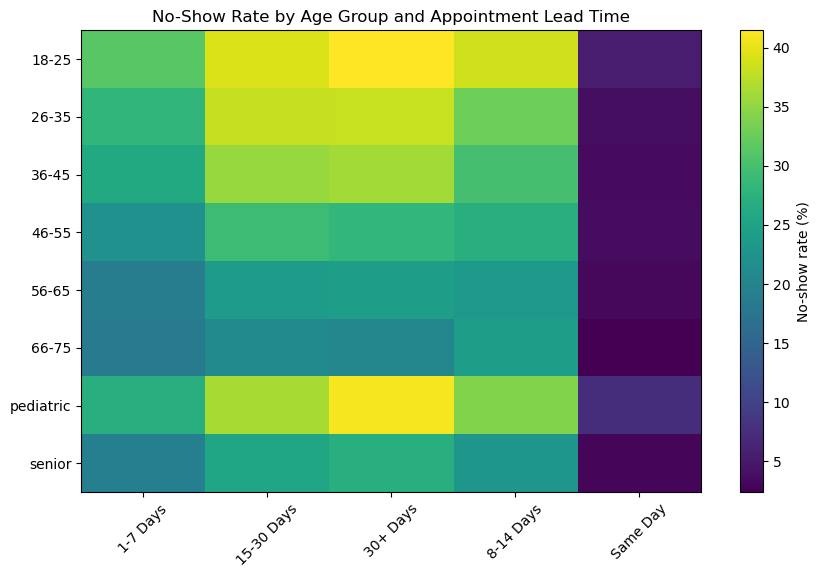

In [28]:
import matplotlib.pyplot as plt

pivot = df_1.pivot(index="age_group", columns="wait_bucket", values="no_show_rate")

plt.figure(figsize=(10,6))
plt.imshow(pivot, aspect="auto")

plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.colorbar(label="No-show rate (%)")
plt.title("No-Show Rate by Age Group and Appointment Lead Time")

plt.show()

## Results

This analysis examined factors associated with patient no-show behavior using appointment-level data, focusing on scheduling lead time, age, SMS reminders, and chronic conditions.

1. Appointment lead time is the primary driver of no-shows

No-show rates increase consistently with longer scheduling lead times. Same-day appointments have the lowest no-show rates (\~2–7%), while appointments scheduled 30+ days in advance show substantially higher rates (\~20–40%). This pattern remains consistent across all age groups.

2. Age modifies baseline risk

Younger patients (18–35) consistently exhibit higher no-show rates across all wait-time categories, while older patients (65+) show lower baseline risk. However, all age groups remain sensitive to increases in appointment lead time, indicating that age modifies but does not override scheduling effects.

3. Highest risk occurs at the intersection of age and wait time

Stratified analysis shows that no-show risk is concentrated among younger patients with long scheduling delays. Conversely, older patients with short lead times consistently exhibit the lowest no-show rates.

4. SMS reminders are associated with higher observed no-show rates due to selection bias

Patients receiving SMS reminders show higher no-show rates across most strata. This likely reflects non-random assignment of SMS reminders to higher-risk patients rather than a causal effect. Within strata, SMS effects are inconsistent and do not indicate uniform improvement in attendance.

5. No-show behavior follows a clear structural gradient

A heatmap of age and wait time reveals a consistent pattern: risk increases with longer lead times and decreases with age. The highest-risk combinations are concentrated among younger patients with long waits, while the lowest-risk combinations are older patients with same-day appointments.

6. Chronic conditions show limited explanatory value

Conditions such as diabetes, hypertension, and alcoholism exhibit weak and inconsistent associations with no-show behavior when evaluated alongside age and scheduling variables. These factors do not meaningfully stratify risk compared to operational and demographic drivers.